In [23]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np

# Création du dataset
X, y = make_blobs(n_samples=100, n_features=2, centers=2, random_state=0)
y = y.reshape((1, y.shape[0]))

print(f"X shape: {X.shape}")  # (100, 2)
print(f"y shape: {y.shape}")  # (1, 100)

X shape: (100, 2)
y shape: (1, 100)


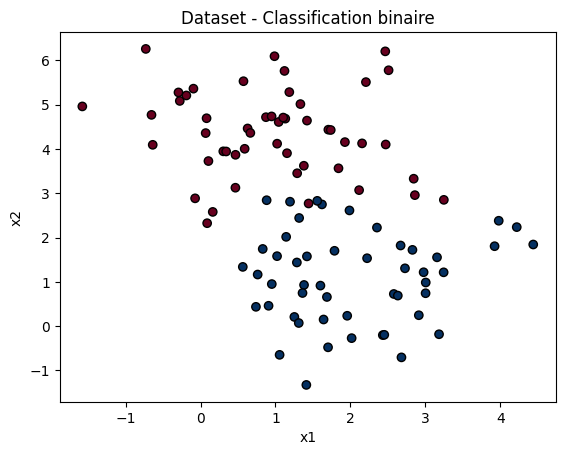

In [24]:
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='RdBu', edgecolors='k')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Dataset - Classification binaire')
plt.show()

In [25]:
def initialisation(X):
    W = np.random.randn(X.shape[1],1)
    b = np.random.randn(1)
    return (W, b)

def model(X, W, b):
    Z = np.dot(X, W) + b
    A = 1 / (1 + np.exp(-Z))  # Sigmoid
    return A

In [26]:
def log_loss(A, y):
    return 1/len(y) * np.sum(-y * np.log(A) - (1 - y) * np.log(1 - A))

log_loss(A,y)


np.float64(8250.456068321566)

In [27]:
def gradients(A,X,y):
    m = len(y)
    dZ = A - y.T
    dW = 1/m * np.dot(X.T, dZ)
    db = 1/m * np.sum(dZ)
    return (dW, db)



In [28]:
def update_parameters(W, b, dW, db, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return (W, b)

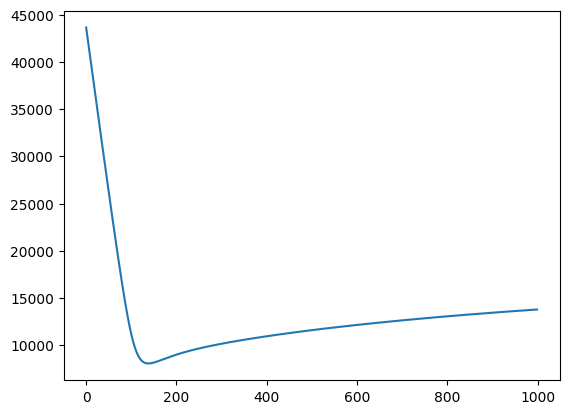

(array([[ 1.35004051],
        [-0.91757843]]),
 array([-0.06354032]))

In [31]:
def artificial_neuron(X, y, learning_rate=0.0001, n_iterations=1000):
    W, b = initialisation(X)

    Loss=[]
    
    for i in range(n_iterations):
        A = model(X, W, b)
        Loss.append(log_loss(A, y))
        dW, db = gradients(A, X, y)
        W, b = update_parameters(W, b, dW, db, learning_rate)

    plt.plot(Loss)
    plt.show()
    
    return W, b

artificial_neuron(X, y)